# Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow.keras import layers
import os
import re, string
import pathlib  # 객체지향 방식으로 파일 경로를 다룸
import urllib.request # url을 통해 파일 다운로드 기능 제공
import tarfile
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\윤원상\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Data

## READ CSV

In [2]:
df = pd.read_csv('.\dataset\PubMed.csv')

## 관련 Column 병합
+ 원하는 자료를 병합하여 1개 column을 검색에 사용할 예정임.

In [3]:
# Title이나 abstractText가 비어있는 경우(NaN) 빈 문자열로 채운 후 병합합니다.
df['Content'] = df['Title'].fillna('') + ": " + df['abstractText'].fillna('')
df['Content'].head()

0    Expression of p53 and coexistence of HPV in pr...
1    Vitamin D status in pregnant Indian women acro...
2    [Identification of a functionally important di...
3    Multilayer capsules: a promising microencapsul...
4    Nanohydrogel with N,N'-bis(acryloyl)cystine cr...
Name: Content, dtype: object

## Punctuation 제거

In [4]:
# 1. Define the function 
def custom_standardization(input_data):
    lowercase = tf.strings.lower(input_data)
    return tf.strings.regex_replace(lowercase, f'[{re.escape(string.punctuation)}]', '')


## Stop word 제거

In [5]:

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if pd.isna(text): return ""
    words = text.split()
    filtered_words = [w for w in words if w.lower() not in stop_words]
    return " ".join(filtered_words)

df['Content'] = df['Content'].apply(remove_stopwords)

## Output 준비

[A] Anatomy: Body parts, tissues, cells.
[B] Organisms: Animals, plants, viruses, bacteria.
[C] Diseases: Pathological conditions, symptoms, injuries.
[D] Chemicals and Drugs: Pharmacological agents, compounds.
[E] Analytical, Diagnostic and Therapeutic Techniques, and Equipment: Techniques, procedures, diagnostic tools.
[F] Psychiatry and Psychology: Mental processes, behaviors.
[G] Phenomena and Processes: Biological/physical processes (e.g., metabolism, genetics).
[H] Disciplines and Occupations: Fields of study, professions.
[I] Anthropology, Education, Sociology, and Social Phenomena: Social aspects of health.
[J] Technology, Industry, and Agriculture: Products, machinery, agricultural techniques.
[K] Humanities: History, ethics, philosophy.
[L] Information Science: Library science, communication, computer science.
[M] Named Groups: Demographic groups, populations.
[N] Health Care: Services, policy, economics, management.
[V] Publication Characteristics: Types of articles (e.g., reviews, clinical trials).
[Z] Geographicals: Countries, regions, locations.

In [6]:
target_cols = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'L', 'M', 'N', 'Z']
num_classes = len(target_cols)
y = df[target_cols].values.astype('float32')
print(f"총 {num_classes}개의 카테고리를 분류합니다.")

총 14개의 카테고리를 분류합니다.


## Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Content'], 
    y, 
    test_size=0.2, 
    random_state=42
)

X_train_arr = np.array(X_train, dtype=object)
X_test_arr = np.array(X_test, dtype=object)
y_train_arr = np.array(y_train).astype('float32')
y_test_arr = np.array(y_test).astype('float32')

print(f"학습 데이터 개수: {len(X_train)}")
print(f"테스트 데이터 개수: {len(X_test)}")

학습 데이터 개수: 40000
테스트 데이터 개수: 10000


## Tokenization

### TextVectorization

In [8]:
vectorize_layer = tf.keras.layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=10000,
    output_mode='int' ,
    output_sequence_length = 250
)

#TFIDF 사용 시 문제 발생
vectorize_layer.adapt(X_train)

# Model

## Embedding Layer & BiLTSM

In [9]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(), dtype=tf.string), 
    # 1. 원문을 숫자 시퀀스로 변환 (250단어)
    vectorize_layer, 
    # 2. 단어의 뉘앙스를 학습하는 고차원 지도 (128차원)
    layers.Embedding(input_dim=10000, output_dim=128),
    # 3. 앞뒤 맥락을 모두 읽는 엔진
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    # 4. 전체 요약 (평균값 추출)
    layers.GlobalAveragePooling1D(),
    
    # 5. 최종 분류를 위한 추론 레이어
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),   
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    # 출력층 (14개 카테고리)
    layers.Dense(num_classes, activation='sigmoid')
])

## Bi-LSTM Layer

## Dense (Hidden) Layers

In [10]:

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,          # 3번의 epoch 동안 기다림
    restore_best_weights=True # 가장 좋았던 상태의 가중치로 복구
)

## Output Layer

In [11]:


model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['binary_accuracy']
)

# [한글 주석] 모델 학습 시작 (X_train 대신 미리 준비한 X_train_arr를 사용해야 합니다)
history = model.fit(
    X_train_arr, y_train_arr,
    epochs=20,                    # Epoch를 넉넉히 잡고 EarlyStopping에 맡깁니다.
    validation_data=(X_test_arr, y_test_arr),
    batch_size=32,
    callbacks=[early_stopping]    # 3. 조기 종료 적용
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 190s 143ms/step - binary_accuracy: 0.8215 - loss: 0.4041 - val_binary_accuracy: 0.8483 - val_loss: 0.3510
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 169s 135ms/step - binary_accuracy: 0.8532 - loss: 0.3442 - val_binary_accuracy: 0.8578 - val_loss: 0.3314
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 176s 140ms/step - binary_accuracy: 0.8634 - loss: 0.3223 - val_binary_accuracy: 0.8649 - val_loss: 0.3169
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 171s 136ms/step - binary_accuracy: 0.8701 - loss: 0.3083 - val_binary_accuracy: 0.8655 - val_loss: 0.3175
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 171s 137ms/step - binary_accuracy: 0.8755 - loss: 0.2970 - val_binary_accuracy: 0.8658 - val_loss: 0.3187
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 171s 137ms/step - binary_accuracy: 0.8807 - loss: 0.2863 - val_binary_accuracy: 0.8647 - val_loss: 0.3254


# Defining "Relevance"

## Option A: The "Explainable" Route (Recommended)

Your model predicts the 16 broad categories. Since you are looking for Pulmonary Diseases, you look at the output for Diseases [C].Logic: If the model's confidence for Diseases [C] is $> 0.8$, you mark it as "Potentially Relevant."Why this is good: It tells you why a paper was picked.

## Option B: The "End-to-End" Route

You create a new "Ground Truth" label in your CSV.

Logic: Any row that has the specific MeSH code for Respiratory Diseases (usually starting with C08) is labeled 1 (Relevant), and everything else is 0 (Not Relevant).

The Model: Your output layer becomes just 1 node (Relevant vs. Not Relevant).

# Visualization

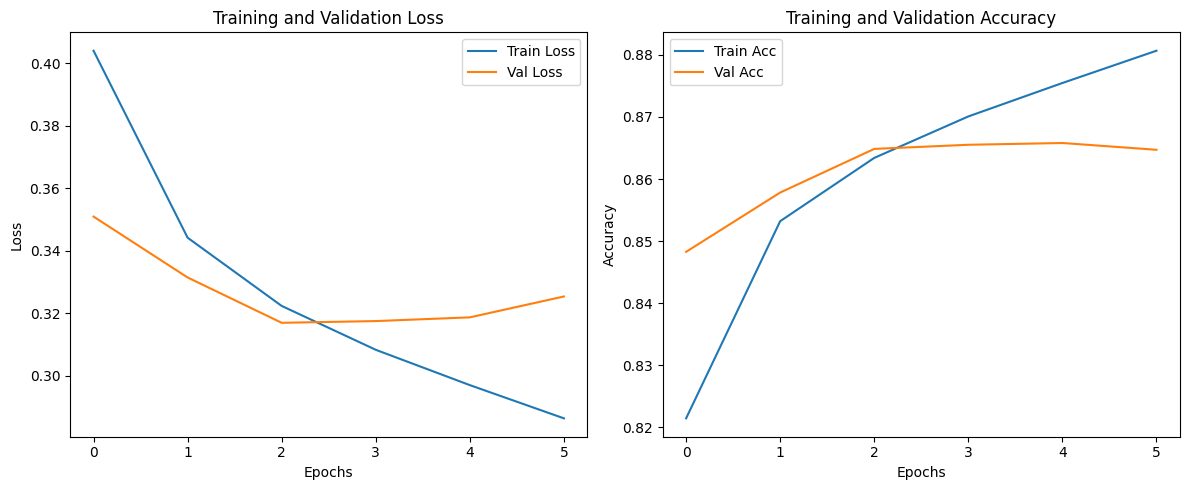

In [12]:
plt.figure(figsize=(12, 5))

# 1. Loss 그래프 (Overfitting 확인용)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 2. Accuracy 그래프 (성능 확인용)
plt.subplot(1, 2, 2)
acc_key = 'binary_accuracy'
plt.plot(history.history[acc_key], label='Train Acc')
plt.plot(history.history[f'val_{acc_key}'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()